# Complete, lightweight feature tour

This notebook is the recommended place to run a new experiment yourself. Change only the **Settings** cell first. The default experiment is deliberately small: two parameters, 12 observations, five alternatives, and short optimization runs.

It demonstrates clean and noisy data, incenter/SL/ASL estimation, prediction metrics, true regret, cone evolution, parameter movement, training loss, loss landscapes, method comparison, uncertainty/influence diagnostics, artifact saving, and an HTML report.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import invoptlab as io
from IPython.display import display
from invoptlab.visualization import (
    plot_geometry_history, plot_loss_landscape_2d,
    plot_run_comparison, plot_training_loss, save_figure,
)

print('invoptlab version:', io.__version__)

invoptlab version: 0.1.0


## 1. Settings

For your first run, leave these values unchanged. Later you can increase `OBSERVATIONS`, `ALTERNATIVES`, or `EPOCHS`. Keep `DIMENSION=2` for the full collection of cone and loss-landscape plots; dimension 3 supports the interactive 3D cone.

In [2]:
SEED = 21
DIMENSION = 2
OBSERVATIONS = 8
ALTERNATIVES = 4
NOISE_PROBABILITY = 0.15
EPOCHS = 20
GEOMETRY_SAMPLES = 150
BOOTSTRAP_REPETITIONS = 2

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
output_dir = root / 'outputs' / 'experiments' / 'my-feature-tour'
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

WindowsPath('C:/Users/payam/Desktop/Inverse Optimization/outputs/experiments/my-feature-tour')

## 2. Create clean and noisy data

The objective is linear in the unknown parameter: $F_\theta(x,s)=\theta^T\phi(s,x)$. Every context contains a small finite set of decisions. The noisy copy randomly replaces about 15% of the demonstrated decisions with another feasible decision.

You can later replace `RandomFeasibleNoise` with `BoltzmannNoise`, `EpsilonOptimalNoise`, `AdditiveNoise`, `BinaryFlipNoise`, or your own object exposing an `apply(...)` method.

In [3]:
problem, clean_data, theta_true = io.random_choice_experiment(
    parameter_dimension=DIMENSION, observations=OBSERVATIONS,
    alternatives=ALTERNATIVES, seed=SEED,
)
_, noisy_data, _ = io.random_choice_experiment(
    parameter_dimension=DIMENSION, observations=OBSERVATIONS,
    alternatives=ALTERNATIVES, true_theta=theta_true,
    noise_model=io.RandomFeasibleNoise(NOISE_PROBABILITY), seed=SEED,
)
changed = sum(bool(obs.noise.get('changed', False)) for obs in noisy_data)
print('true theta:', np.round(theta_true, 4))
print(f'noisy demonstrations changed: {changed}/{len(noisy_data)}')
display(pd.DataFrame([io.summarize_dataset(clean_data, problem), io.summarize_dataset(noisy_data, problem)]))

true theta: [0.5817 0.8134]
noisy demonstrations changed: 2/8


,name,size,fingerprint,weight_sum,timestamped_fraction,ground_truth_theta_fraction,clean_decision_fraction,experts,noise_types,validation_warnings
0,random-choice-data,8,88420afef641e088939c498798f6ee28ae179a70d2ae30...,8.0,1.0,1.0,1.0,[],{'none': 8},[]
1,random-choice-data,8,98606cefaa83fde77cb775cdacf952cf4771ba4a2a71f3...,8.0,1.0,1.0,1.0,[],{'random_feasible': 8},[]


## 3. Fit three inverse estimators

- **Incenter** uses exact clean consistency hyperplanes and records how the cone center moves.
- **SL** minimizes suboptimality loss on noisy observations.
- **ASL + CVaR** uses a decision-aware margin and emphasizes the worst 30% of demonstration losses.

In [4]:
runner_clean = io.ExperimentRunner(io.ExperimentConfig(
    name='clean-incenter', seed=SEED, geometry_samples=GEOMETRY_SAMPLES))
runner_noisy = io.ExperimentRunner(io.ExperimentConfig(
    name='noisy-learning', seed=SEED, geometry_samples=GEOMETRY_SAMPLES))

incenter_result = runner_clean.run(
    problem, clean_data, io.IncenterEstimator(sequential_history=True))
sl_result = runner_noisy.run(
    problem, noisy_data, io.ProjectedSubgradientEstimator(
        loss=io.SuboptimalityLoss(), epochs=EPOCHS, learning_rate=0.25,
        record_every=5, seed=SEED))
asl_result = runner_noisy.run(
    problem, noisy_data, io.ProjectedSubgradientEstimator(
        loss=io.AugmentedSuboptimalityLoss(), risk=io.CVaRRisk(0.30),
        epochs=EPOCHS, learning_rate=0.25, record_every=5, seed=SEED))

results = [incenter_result, sl_result, asl_result]
comparison = pd.DataFrame([{
    'method': result.name,
    'theta': np.round(result.theta, 4),
    'clean accuracy': result.metrics.get('clean_decision_accuracy'),
    'mean true regret': result.metrics.get('mean_true_regret'),
    'cosine similarity': result.metrics.get('parameter_cosine_similarity'),
    'constraint violation': result.metrics.get('constraint_violation_rate'),
    'fit seconds': result.metrics.get('fit_time_seconds'),
} for result in results])
display(comparison)

,method,theta,clean accuracy,mean true regret,cosine similarity,constraint violation,fit seconds
0,clean-incenter,"[0.6155, 0.7881]",1.00,0.000000,0.999106,0.000000,1.046261
1,noisy-learning,"[-0.0189, 0.0216]",0.25,0.945551,0.227361,0.208333,0.014664
2,noisy-learning,"[-0.0506, 0.0401]",0.25,1.164070,0.048946,0.291667,0.022500


## 4. Consistency cone and its evolution

The pale lines are demonstration-induced hyperplanes. Their intersection with the normalized parameter domain is the feasible consistency region. The star is the incenter, the orange point is the estimate, and the green cross is the ground truth. Use the slider below the interactive figure to replay how the cone changes after each observation.

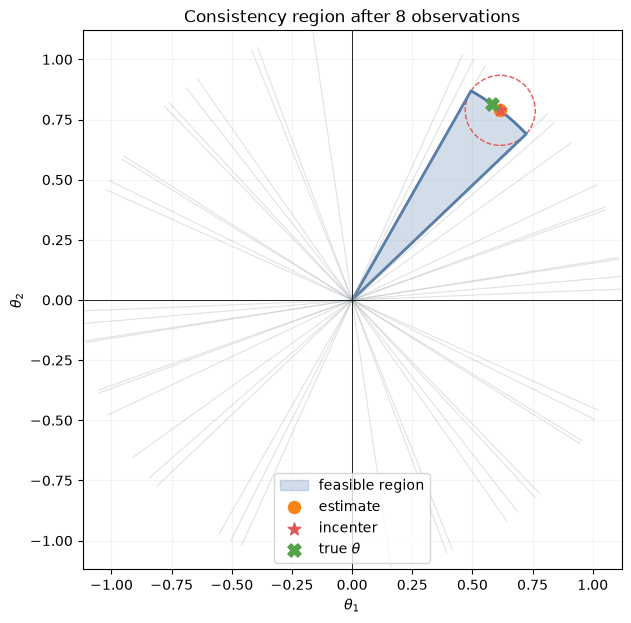

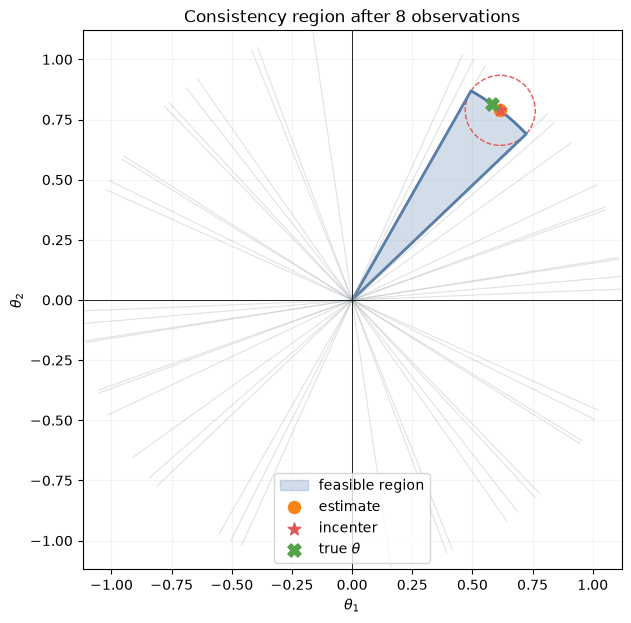

In [5]:
cone_figure = incenter_result.plot_cone(problem, true_theta=theta_true)
display(cone_figure)
cone_animation = incenter_result.animate_cone(problem, true_theta=theta_true)
display(cone_animation)

## 5. Parameter, geometry, loss, and regret diagnostics

These plots answer different questions: Does the estimate stabilize? Does the feasible cone shrink? Does the training objective decrease? Which observations create regret?

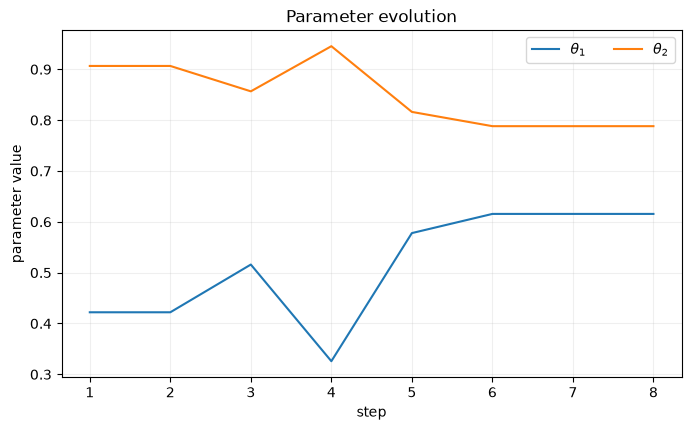

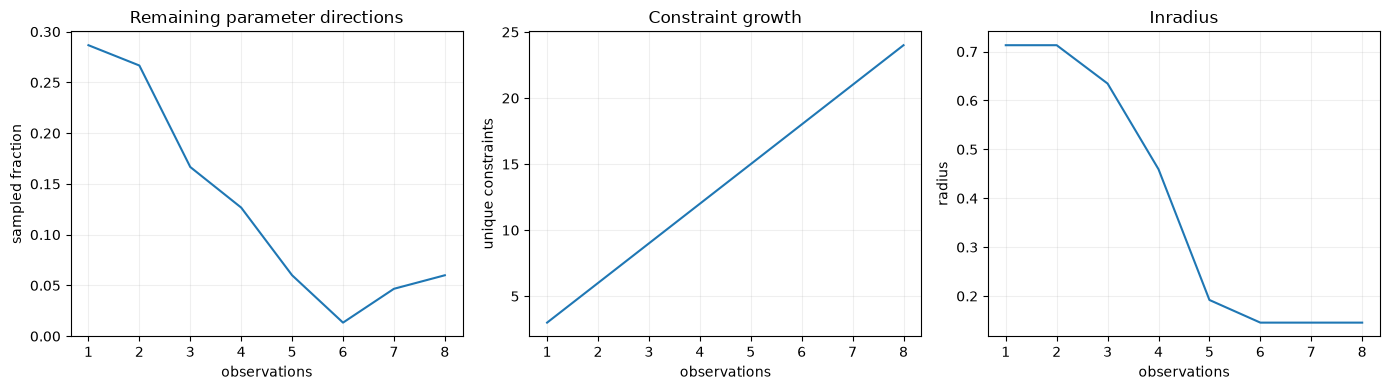

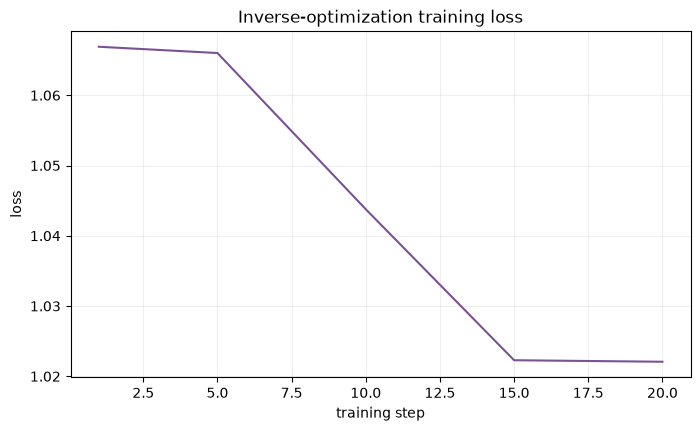

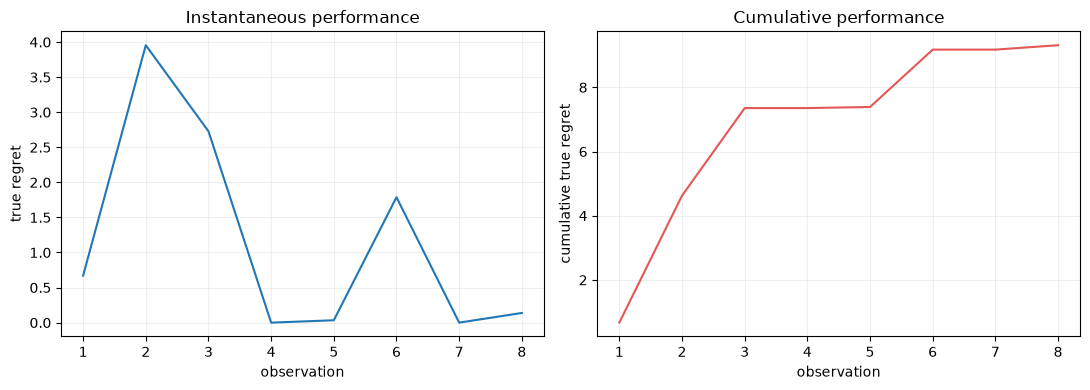

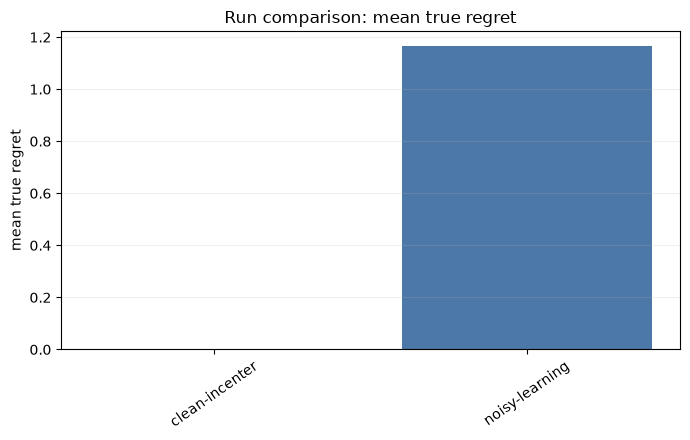

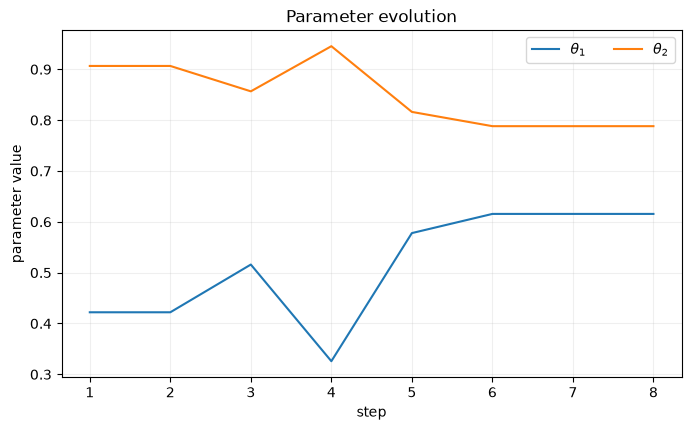

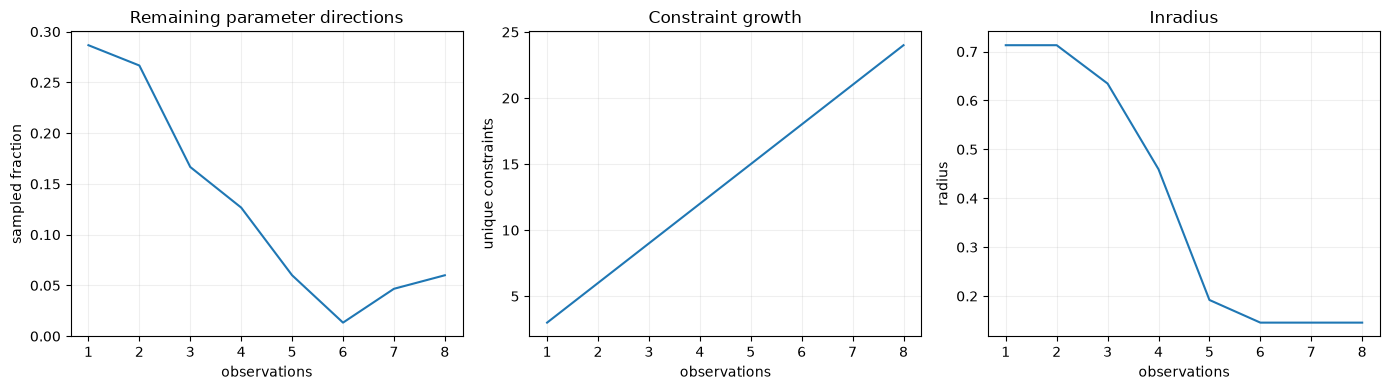

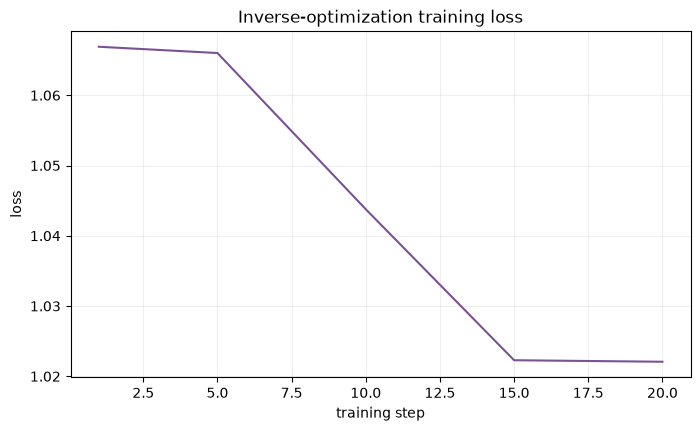

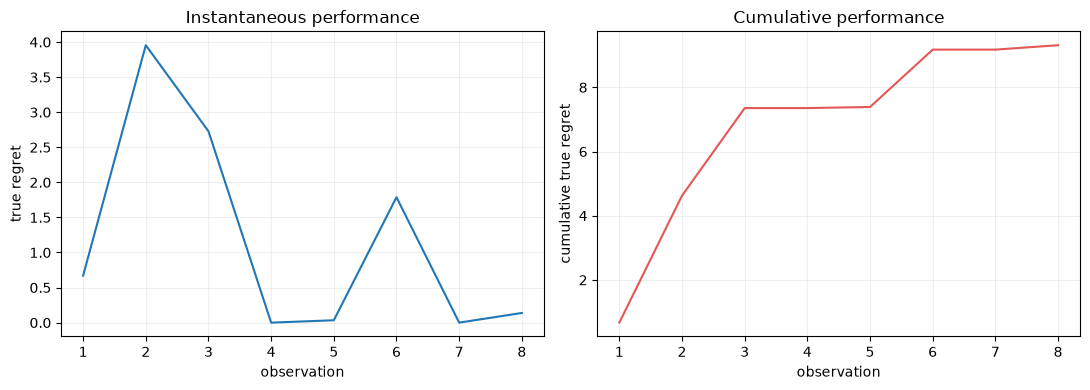

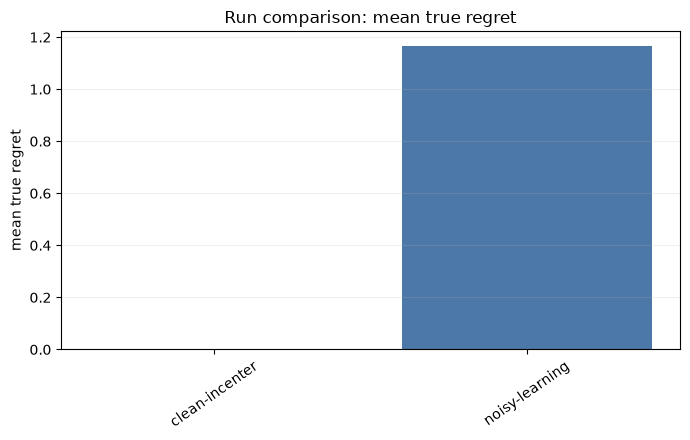

In [6]:
parameter_figure = incenter_result.plot_parameters()
geometry_figure = plot_geometry_history(incenter_result)
training_figure = plot_training_loss(asl_result)
regret_figure = asl_result.plot_regret()
comparison_figure = plot_run_comparison(results, 'mean_true_regret')
for figure in [parameter_figure, geometry_figure, training_figure, regret_figure, comparison_figure]:
    display(figure)

## 6. Loss landscape over $\theta$

This contour plot evaluates ASL across the two-dimensional parameter domain. Increase `resolution` only when you want a finer but slower plot.

In [7]:
loss_figure = plot_loss_landscape_2d(
    problem, noisy_data, io.AugmentedSuboptimalityLoss(),
    result=asl_result, resolution=17)
display(loss_figure)

## 7. Lightweight uncertainty and influence analysis

Bootstrap resampling measures parameter uncertainty. Leave-one-out influence identifies demonstrations that move the estimate most. Four bootstrap repetitions are only for a quick demonstration; use 100 or more for research conclusions.

In [8]:
factory = lambda: io.IncenterEstimator(sequential_history=False)
bootstrap = io.bootstrap_parameters(
    factory, problem, clean_data, repetitions=BOOTSTRAP_REPETITIONS, seed=SEED)
influence = io.leave_one_out_influence(factory, problem, clean_data)
display(pd.DataFrame({
    'theta component': np.arange(1, DIMENSION + 1),
    'bootstrap mean': bootstrap.mean,
    'standard error': bootstrap.standard_error,
    'lower 95%': bootstrap.lower,
    'upper 95%': bootstrap.upper,
}))
display(pd.DataFrame({'observation': np.arange(1, len(clean_data) + 1), 'influence': influence})
        .sort_values('influence', ascending=False).head())

,theta component,bootstrap mean,standard error,lower 95%,upper 95%
0,1,0.615530,1.554392e-14,0.615530,0.615530
1,2,0.788113,1.208971e-14,0.788113,0.788113


,observation,influence
5,6,2.466079e-02
3,4,2.081394e-02
1,2,8.623353e-14
6,7,9.815276e-15
7,8,9.796421e-15


## 8. Save everything

This cell writes reusable data, numerical summaries, figures, an interactive cone animation, and a standalone report. You can reopen the HTML files without Jupyter.

In [9]:
io.save_json(noisy_data, output_dir / 'noisy_dataset.json')
incenter_result.save(output_dir / 'incenter')
sl_result.save(output_dir / 'sl')
asl_result.save(output_dir / 'asl')
save_figure(cone_figure, str(output_dir / 'final_cone.png'))
save_figure(cone_animation, str(output_dir / 'cone_evolution.html'))
save_figure(loss_figure, str(output_dir / 'loss_landscape.html'))
save_figure(parameter_figure, str(output_dir / 'parameter_history.png'))
save_figure(geometry_figure, str(output_dir / 'geometry_history.png'))
save_figure(training_figure, str(output_dir / 'training_loss.png'))
save_figure(regret_figure, str(output_dir / 'regret.png'))
save_figure(comparison_figure, str(output_dir / 'method_comparison.png'))
report_path = asl_result.generate_report(
    problem, noisy_data, output_dir / 'report.html',
    loss=io.AugmentedSuboptimalityLoss())
print('All outputs saved to:', output_dir.relative_to(root))
print('Open this report:', report_path.relative_to(root))

All outputs saved to: outputs\experiments\my-feature-tour
Open this report: outputs\experiments\my-feature-tour\report.html


## 9. What to change next

1. Replace the generated dataset with `InverseDataset.from_records(...)`, `load_csv(...)`, or `load_json(...)`.
2. Define your own $\phi(s,x)$ with `finite_choice_problem(...)`, as shown in notebook 02.
3. Try `MeanRisk`, `CVaRRisk`, `TrimmedMeanRisk`, or `QuantileRisk`.
4. Try stochastic or mirror descent by setting `stochastic=True` or `mirror_descent=True`.
5. Use `OnlineEstimator` for observation-by-observation learning.
6. Use `ScipyOracle`, `CallableOracle`, or optional `CVXPYOracle` for continuous/custom forward problems.
7. Switch to dimension 3 and follow notebook 04 for the interactive 3D consistency region.